💡 複数のフレームが検出されました。最初のフレームを抽出します。
✅ 4列目（信頼度スコア）を削除し、3次元座標のみを抽出しました。
✅ データ準備完了。最終形状: (17, 3)


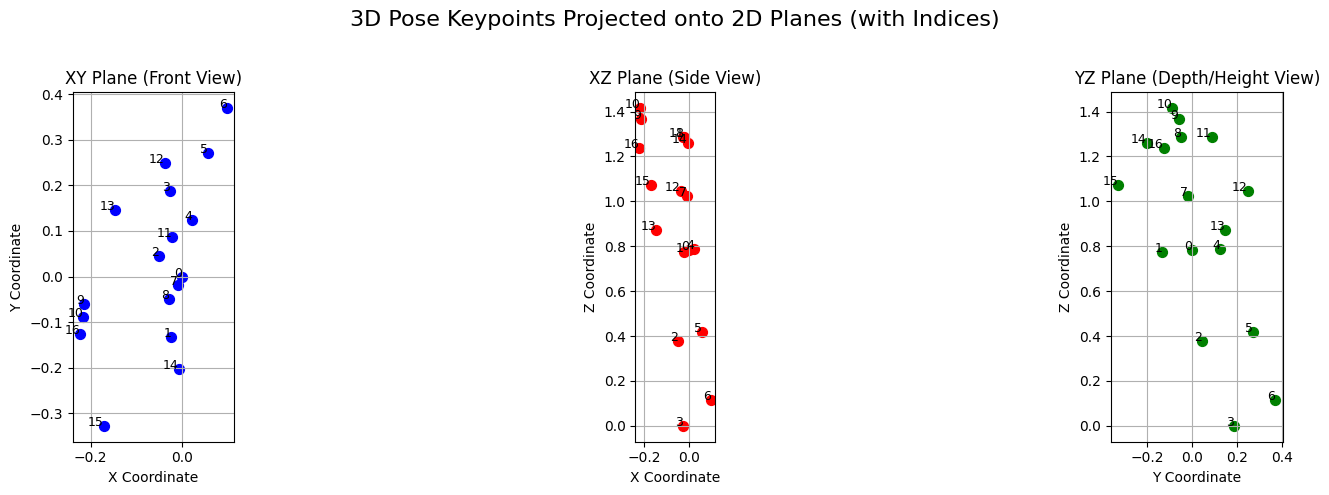

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ====================================================================
# ユーザー設定 (前回から変更なし)
# ====================================================================

# 読み込むNPZファイルのパスを指定してください
NPZ_FILEPATH = "C:/Users/a24k0/R6_blender/scripts/keypoints.npz" 
DATA_KEY_NAME = 'keypoints_3d' 

# ====================================================================
# 1. データの読み込みと整形 (前回から変更なし)
# ====================================================================

def load_and_prepare_pose_data(filepath, data_key):
    """NPZファイルからデータを読み込み、4列目を削除し、(17, 3)に整形する"""
    if not os.path.exists(filepath):
        print(f"❌ エラー: ファイルが見つかりません: {filepath}")
        return None

    try:
        data = np.load(filepath)
    except Exception as e:
        print(f"❌ エラー: NPZファイルの読み込み中に問題が発生しました: {e}")
        return None

    if data_key not in data:
        print(f"❌ エラー: NPZファイル内にキー '{data_key}' が見つかりません。")
        print(f"💡 存在するキー: {list(data.keys())}")
        return None

    keypoints_data = data[data_key]
    
    # 複数のフレームが含まれている場合、最初のフレーム ([0]) を取得
    if keypoints_data.ndim == 3:
        keypoints_data = keypoints_data[0]
        print("💡 複数のフレームが検出されました。最初のフレームを抽出します。")

    # 4列目（信頼度スコア）を削除する処理
    if keypoints_data.shape[-1] == 4:
        coordinates_3d = keypoints_data[:, :3]
        print("✅ 4列目（信頼度スコア）を削除し、3次元座標のみを抽出しました。")
    elif keypoints_data.shape[-1] == 3:
        coordinates_3d = keypoints_data
        print("✅ データは既に3次元座標 (X, Y, Z) のみです。")
    else:
        print(f"❌ エラー: データの最終次元が想定外です。期待: 3 or 4、実際: {keypoints_data.shape[-1]}")
        return None
    
    # 最終的な形状の検証
    if coordinates_3d.shape != (17, 3):
        print(f"❌ エラー: 処理後のキーポイント配列の形状が (17, 3) ではありません: {coordinates_3d.shape}")
        return None
        
    print(f"✅ データ準備完了。最終形状: {coordinates_3d.shape}")
    return coordinates_3d

# ====================================================================
# 2. プロット関数 (ナンバー表示機能を追加)
# ====================================================================

def plot_3d_keypoints_2d(coordinates_3d):
    """
    17x3の座標データを2次元サブプロットにプロットし、各点にインデックスを表示する。
    """
    X = coordinates_3d[:, 0]
    Y = coordinates_3d[:, 1]
    Z = coordinates_3d[:, 2]
    # 0から16までのインデックス配列を生成
    indices = np.arange(len(X)) 

    # プロット領域の設定 (1行3列)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('3D Pose Keypoints Projected onto 2D Planes (with Indices)', fontsize=16)

    # --- 1. XY 平面プロット (正面/上面視) ---
    axes[0].scatter(X, Y, s=50, c='blue', marker='o')
    axes[0].set_title('XY Plane (Front View)')
    axes[0].set_xlabel('X Coordinate')
    axes[0].set_ylabel('Y Coordinate')
    axes[0].grid(True)
    axes[0].set_aspect('equal', adjustable='box') 
    
    # 各点にインデックスを表示
    for i, txt in enumerate(indices):
        # plt.text(x座標, y座標, 表示テキスト, オフセット, フォントサイズ)
        axes[0].text(X[i], Y[i], str(txt), fontsize=9, ha='right')

    # --- 2. XZ 平面プロット (側面視) ---
    axes[1].scatter(X, Z, s=50, c='red', marker='o')
    axes[1].set_title('XZ Plane (Side View)')
    axes[1].set_xlabel('X Coordinate')
    axes[1].set_ylabel('Z Coordinate')
    axes[1].grid(True)
    axes[1].set_aspect('equal', adjustable='box')
    
    # 各点にインデックスを表示
    for i, txt in enumerate(indices):
        axes[1].text(X[i], Z[i], str(txt), fontsize=9, ha='right')
    
    # --- 3. YZ 平面プロット (奥行き/側面視) ---
    axes[2].scatter(Y, Z, s=50, c='green', marker='o')
    axes[2].set_title('YZ Plane (Depth/Height View)')
    axes[2].set_xlabel('Y Coordinate')
    axes[2].set_ylabel('Z Coordinate')
    axes[2].grid(True)
    axes[2].set_aspect('equal', adjustable='box')

    # 各点にインデックスを表示
    for i, txt in enumerate(indices):
        axes[2].text(Y[i], Z[i], str(txt), fontsize=9, ha='right')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ====================================================================
# 3. 実行
# ====================================================================

# 1. データ読み込みと整形
pose_coords = load_and_prepare_pose_data(NPZ_FILEPATH, DATA_KEY_NAME)

# 2. プロット
if pose_coords is not None:
    plot_3d_keypoints_2d(pose_coords)